## Overview

Develop a sentiment analysis model using NLP techniques based on emotions dataset

Dataset: https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp/data



### Importing the libraries

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

## Data loading

Loading the dataset as dataframes

In [27]:
df_train = pd.read_csv("train.txt", delimiter=';',names=['text','label'])
df_val = pd.read_csv("val.txt", delimiter=';',names=['text','label'])

In [28]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [29]:
df_val.head()

,text,label
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy


## Data Concatenation

Concatenating the training and validation DataFrames into a single unified dataset, as we have a separate test dataset.


In [30]:
df_full = pd.concat([df_train, df_val], axis=0).reset_index(drop=True)
print(f"Shape of df_full: {df_full.shape}")
df_full.head()

Shape of df_full: (18000, 2)


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## Data Cleaning

Cleaning the text data in df_full by removing special characters, ensuring lowercase consistency, and handling duplicates.


In [31]:
def clean_text(text):
    # Remove special characters and punctuation, keep alphanumeric and spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

# Record initial shape
initial_shape = df_full.shape
print(f"Initial shape: {initial_shape}")

# 1. Convert to lowercase
df_full['text'] = df_full['text'].str.lower()

# 2. Apply cleaning function
df_full['text'] = df_full['text'].apply(clean_text)

# 3. Handle duplicates
df_full = df_full.drop_duplicates().reset_index(drop=True)

# 4. Handle missing values
df_full = df_full.dropna(subset=['text', 'label'])

# 5. Print final shape
final_shape = df_full.shape
print(f"Final shape: {final_shape}")
print(f"Removed {initial_shape[0] - final_shape[0]} records.")
df_full.head()

Initial shape: (18000, 2)
Final shape: (17999, 2)
Removed 1 records.


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## Feature Engineering

Creating new features such as text length, word count, and average word length to assist in the exploratory analysis.


In [32]:
import numpy as np

# 1. Calculate text length (character count)
df_full['text_length'] = df_full['text'].apply(len)

# 2. Calculate word count
df_full['word_count'] = df_full['text'].apply(lambda x: len(x.split()))

# 3. Calculate average word length
# Use a lambda to avoid division by zero if any empty strings exist
df_full['avg_word_length'] = df_full.apply(lambda row: row['text_length'] / row['word_count'] if row['word_count'] > 0 else 0, axis=1)

# 4. Display the first few rows
print("Features engineered successfully.")
df_full.head()

Features engineered successfully.


,text,label,text_length,word_count,avg_word_length
0,i didnt feel humiliated,sadness,23,4,5.750000
1,i can go from feeling so hopeless to so damned...,sadness,108,21,5.142857
2,im grabbing a minute to post i feel greedy wrong,anger,48,10,4.800000
3,i am ever feeling nostalgic about the fireplac...,love,92,18,5.111111
4,i am feeling grouchy,anger,20,4,5.000000


## Exploratory Data Analysis (EDA) & Visualization

Analyzing the distribution of emotion labels and text features


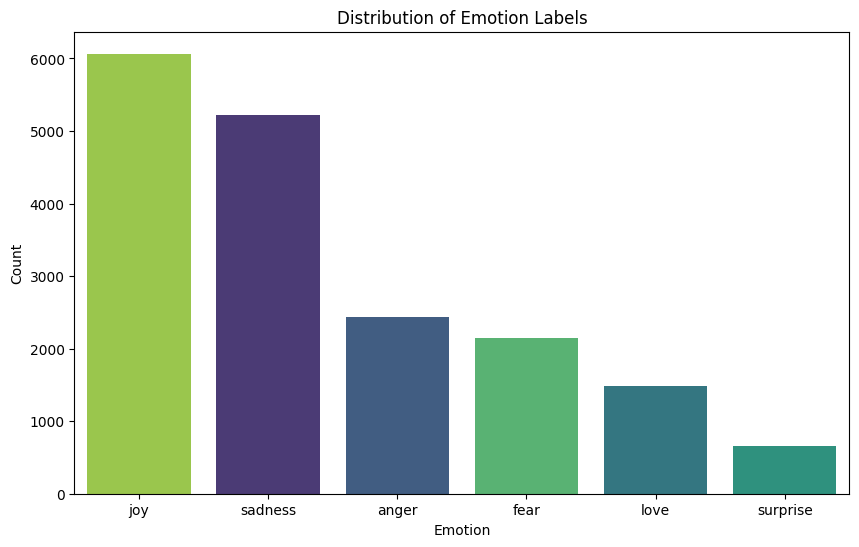

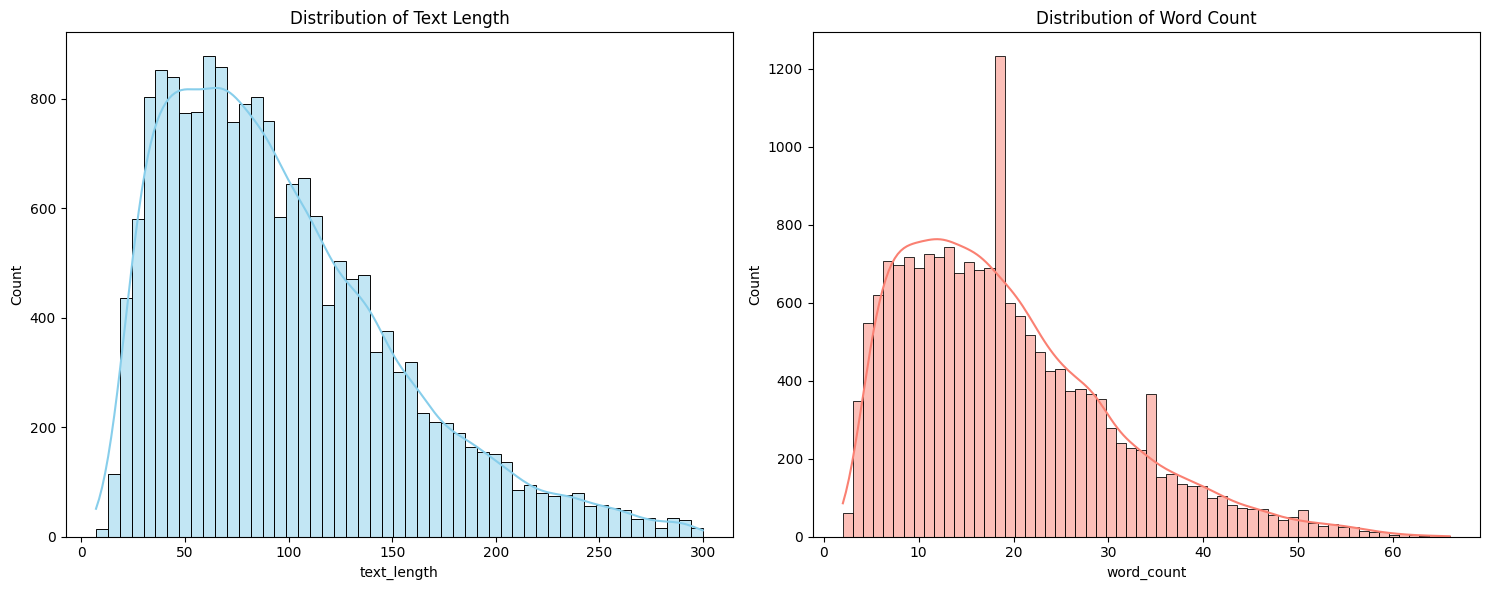

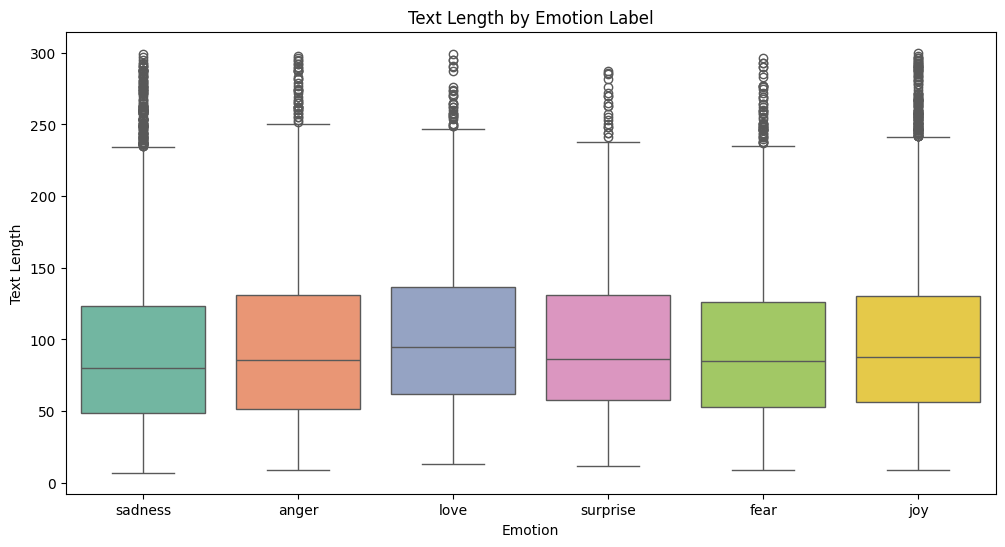

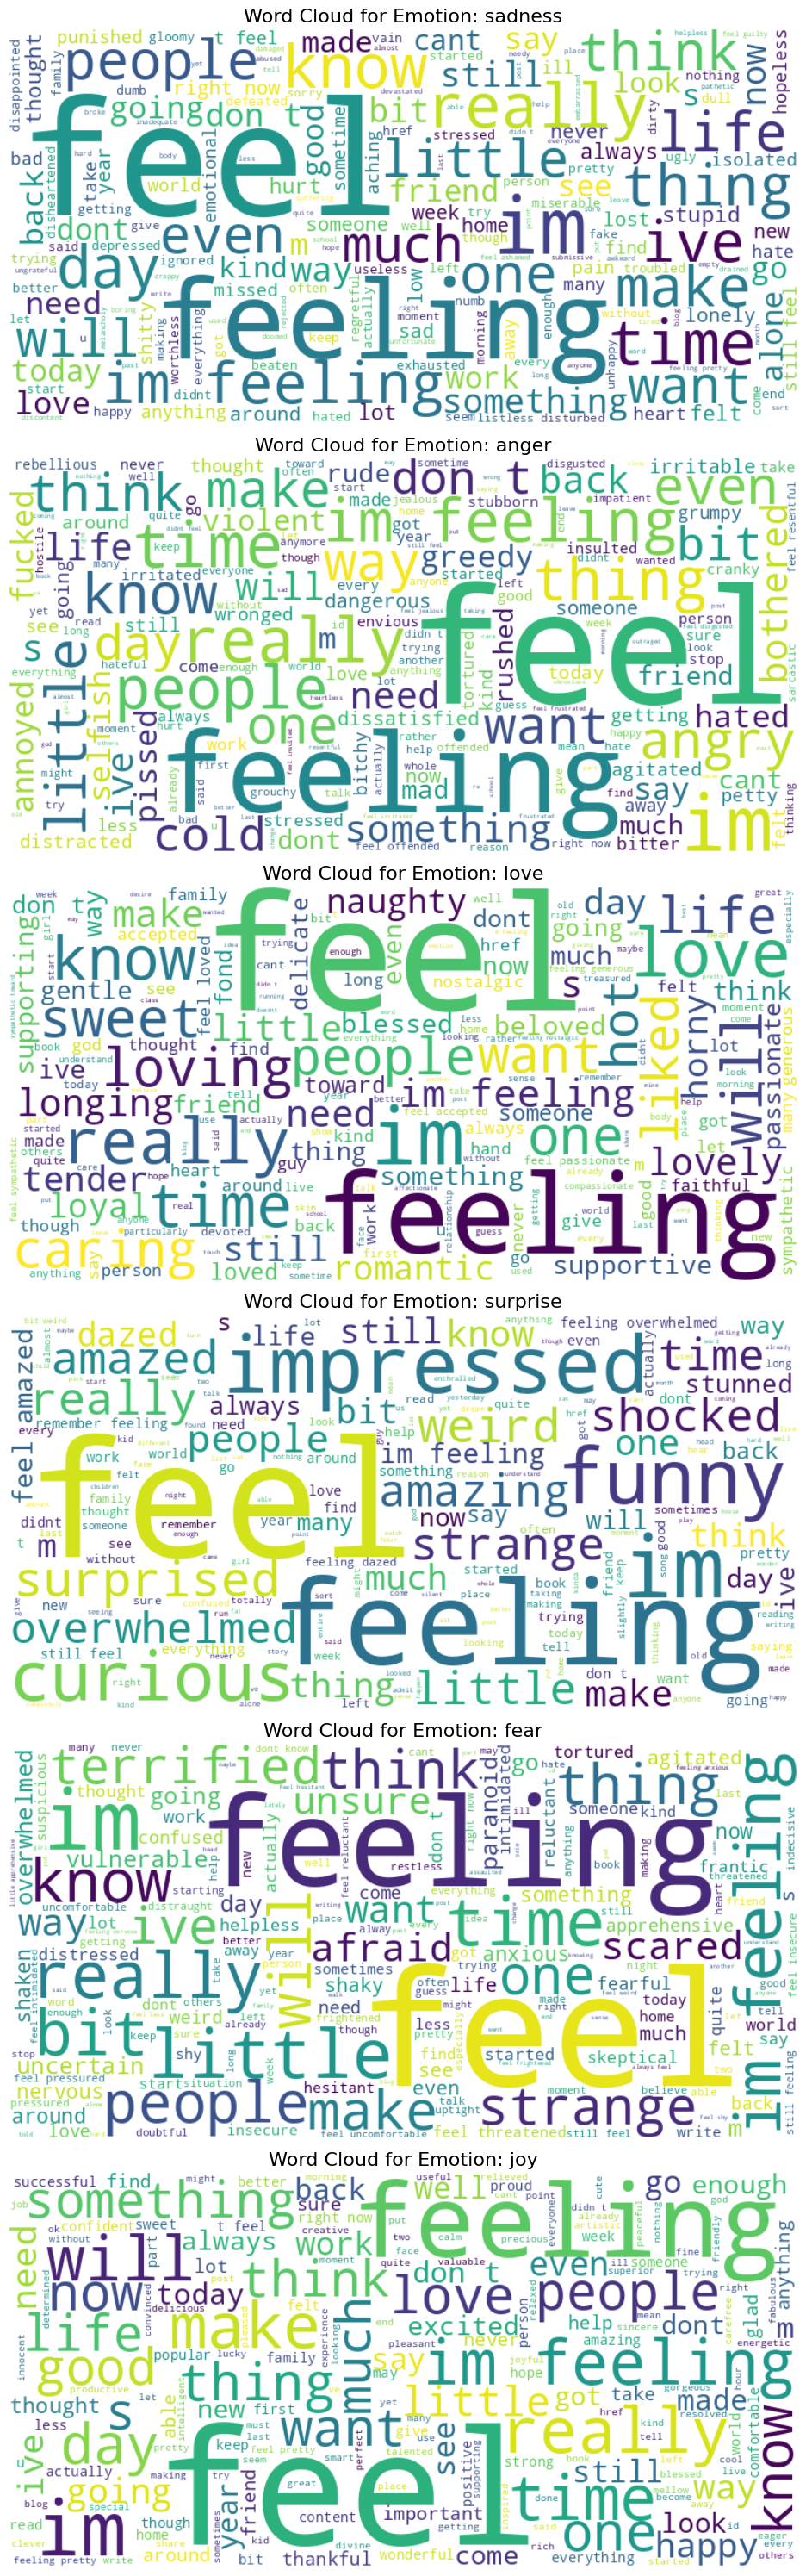

In [33]:
# 1. Label distribution count plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df_full, x='label', order=df_full['label'].value_counts().index, palette='viridis', hue='label', legend=False)
plt.title('Distribution of Emotion Labels')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.show()

# 2. Histograms for text_length and word_count
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(df_full['text_length'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Text Length')
sns.histplot(df_full['word_count'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Word Count')
plt.tight_layout()
plt.show()

# 3. Box plot: text_length by label
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_full, x='label', y='text_length', palette='Set2', hue='label', legend=False)
plt.title('Text Length by Emotion Label')
plt.xlabel('Emotion')
plt.ylabel('Text Length')
plt.show()

# 4. Word Clouds for each emotion
emotions = df_full['label'].unique()
fig, axes = plt.subplots(len(emotions), 1, figsize=(10, 5 * len(emotions)))

for i, emotion in enumerate(emotions):
    text_data = " ".join(df_full[df_full['label'] == emotion]['text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'Word Cloud for Emotion: {emotion}', fontsize=16)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Baseline Model Development

Preparing the data using TF-IDF vectorization, train a Multinomial Naive Bayes classifier, and evaluate its performance.


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Define feature matrix X and target vector y
X = df_full['text']
y = df_full['label']

# 2. Split the data into training and testing sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize TfidfVectorizer and transform the text data
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

# 4. Initialize and train the Multinomial Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 5. Generate predictions and evaluate the model
y_pred = model.predict(X_test_tfidf)
print("Baseline Model: Multinomial Naive Bayes Classification Report")
print(classification_report(y_test, y_pred, zero_division=0))

Baseline Model: Multinomial Naive Bayes Classification Report
              precision    recall  f1-score   support

       anger       0.96      0.18      0.31       500
        fear       0.85      0.10      0.18       399
         joy       0.54      0.99      0.70      1150
        love       1.00      0.02      0.04       304
     sadness       0.71      0.87      0.79      1109
    surprise       0.00      0.00      0.00       138

    accuracy                           0.62      3600
   macro avg       0.68      0.36      0.34      3600
weighted avg       0.71      0.62      0.53      3600



### Addressing Class Imbalance with Oversampling

We will use `RandomOverSampler` to balance our training data and see if it improves the recall for minority classes like 'surprise'.

In [35]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# 1. Initialize the RandomOverSampler
ros = RandomOverSampler(random_state=42)

# 2. Resample the training data (TF-IDF features)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_tfidf, y_train)

print(f"Original training class distribution: {Counter(y_train)}")
print(f"Resampled training class distribution: {Counter(y_train_resampled)}")

# 3. Train the model on the balanced dataset
model_balanced = MultinomialNB()
model_balanced.fit(X_train_resampled, y_train_resampled)

# 4. Evaluate on the original (unbalanced) test set
y_pred_balanced = model_balanced.predict(X_test_tfidf)

print("\nModel with Oversampling: Multinomial Naive Bayes Classification Report")
print(classification_report(y_test, y_pred_balanced, zero_division=0))

Original training class distribution: Counter({'joy': 4915, 'sadness': 4107, 'anger': 1934, 'fear': 1750, 'love': 1178, 'surprise': 515})
Resampled training class distribution: Counter({'sadness': 4915, 'joy': 4915, 'fear': 4915, 'anger': 4915, 'surprise': 4915, 'love': 4915})

Model with Oversampling: Multinomial Naive Bayes Classification Report
              precision    recall  f1-score   support

       anger       0.78      0.83      0.81       500
        fear       0.71      0.77      0.74       399
         joy       0.91      0.80      0.85      1150
        love       0.61      0.84      0.70       304
     sadness       0.92      0.83      0.87      1109
    surprise       0.49      0.71      0.58       138

    accuracy                           0.81      3600
   macro avg       0.74      0.80      0.76      3600
weighted avg       0.83      0.81      0.82      3600



### Feature importance of engineered features

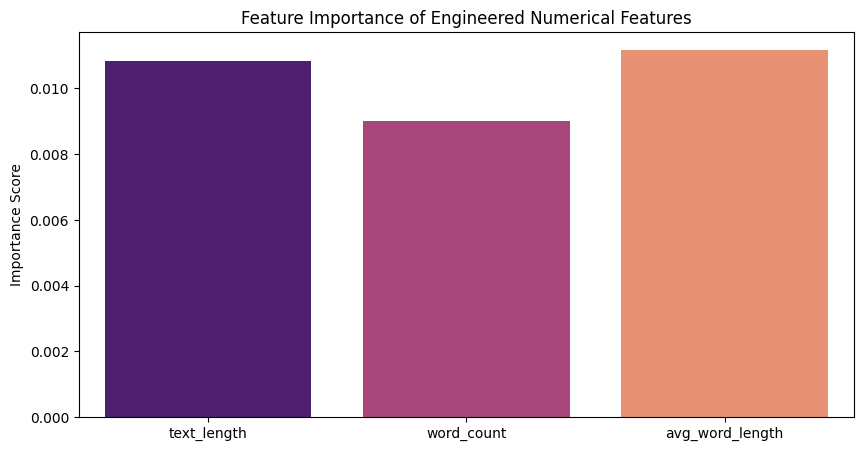

Total features (Words + Engineered): 14344
'text_length' Importance: 0.0108 (Ranked 2 out of 14344)
'word_count' Importance: 0.0090 (Ranked 4 out of 14344)
'avg_word_length' Importance: 0.0112 (Ranked 1 out of 14344)


In [36]:
from sklearn.ensemble import RandomForestClassifier
import scipy.sparse as sp

# 1. Combine TF-IDF features with engineered numerical features
X_engineered = df_full[['text_length', 'word_count', 'avg_word_length']].values
# Use y_train index to align the engineered features with the split training data
X_combined = sp.hstack((X_train_tfidf, X_engineered[y_train.index]))

# 2. Train a Random Forest to get feature importances
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_combined, y_train)

# 3. Extract importance of the 3 engineered features
importances = rf.feature_importances_
num_tfidf_features = X_train_tfidf.shape[1]
eng_importances = importances[num_tfidf_features:]
eng_feature_names = ['text_length', 'word_count', 'avg_word_length']

# 4. Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=eng_feature_names, y=eng_importances, palette='magma', hue=eng_feature_names, legend=False)
plt.title('Feature Importance of Engineered Numerical Features')
plt.ylabel('Importance Score')
plt.show()

print(f"Total features (Words + Engineered): {len(importances)}")
for name, imp in zip(eng_feature_names, eng_importances):
    rank = (importances > imp).sum() + 1
    print(f"'{name}' Importance: {imp:.4f} (Ranked {rank} out of {len(importances)})")

### Hyperparameter Tuning with GridSearchCV

To optimize our Random Forest model, we use `GridSearchCV` to systematically explore combinations of parameters such as `n_estimators`, `max_depth`, and `min_samples_split`.

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import scipy.sparse as sp

# 1. Prepare combined features for test set alignment
X_eng_test = df_full[['text_length', 'word_count', 'avg_word_length']].values
X_test_combined = sp.hstack((X_test_tfidf, X_eng_test[y_test.index]))

# 2. parameter grid
parameters = {
    'max_features': ['sqrt'],
    'n_estimators': [100, 300], #
    'max_depth': [10, None],
    'min_samples_split': [5, 15],
    'min_samples_leaf': [1, 5],
    'bootstrap': [True]
}

# 3. Initialize the Classifier and GridSearchCV
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(estimator=rf_base, param_grid=parameters, cv=2, scoring='accuracy', verbose=1)

# 4. Fit the model
print("Starting Shortened Grid Search...")
grid_search.fit(X_combined, y_train)

# 5. Display results
print(f"Best Parameters found: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

# 6. Final Evaluation
y_pred_final = best_model.predict(X_test_combined)
print("\nTuned Random Forest Classification Report:")
print(classification_report(y_test, y_pred_final, zero_division=0))

Starting Shortened Grid Search...
Fitting 2 folds for each of 16 candidates, totalling 32 fits
Best Parameters found: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 15, 'n_estimators': 300}

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

       anger       0.89      0.80      0.84       500
        fear       0.82      0.78      0.80       399
         joy       0.80      0.94      0.86      1150
        love       0.87      0.67      0.76       304
     sadness       0.92      0.88      0.90      1109
    surprise       0.83      0.70      0.76       138

    accuracy                           0.85      3600
   macro avg       0.86      0.79      0.82      3600
weighted avg       0.86      0.85      0.85      3600



### Final Model Training and Evaluation

Using the best parameters identified during the grid search, we initialize and train our final Random Forest classifier on the combined training set (TF-IDF + Engineered Features).

In [38]:
from sklearn.metrics import classification_report

# 1. Initialize the Random Forest with the best parameters from Grid Search
final_rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=15,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# 2. Train the final model on the combined training set (TF-IDF + Engineered)
print("Training the final Random Forest model with optimized parameters...")
final_rf_model.fit(X_combined, y_train)

# 3. Final performance check on the test set
X_eng_test = df_full[['text_length', 'word_count', 'avg_word_length']].values
X_test_combined = sp.hstack((X_test_tfidf, X_eng_test[y_test.index]))
y_pred_final = final_rf_model.predict(X_test_combined)

print("\nFinal Optimized Model Classification Report:")
print(classification_report(y_test, y_pred_final, zero_division=0))

Training the final Random Forest model with optimized parameters...

Final Optimized Model Classification Report:
              precision    recall  f1-score   support

       anger       0.89      0.80      0.84       500
        fear       0.82      0.78      0.80       399
         joy       0.80      0.94      0.86      1150
        love       0.87      0.67      0.76       304
     sadness       0.92      0.88      0.90      1109
    surprise       0.83      0.70      0.76       138

    accuracy                           0.85      3600
   macro avg       0.86      0.79      0.82      3600
weighted avg       0.86      0.85      0.85      3600



### Evaluation on the Unseen Test Dataset

Finally, we prepare the separate `test.txt` dataset using the same cleaning and feature engineering pipeline to evaluate the model's true generalization performance.

In [39]:
df_test = pd.read_csv("test.txt", delimiter=';',names=['text','label'])
# 1. Data Cleaning for df_test
df_test['text'] = df_test['text'].str.lower()
df_test['text'] = df_test['text'].apply(clean_text)
df_test = df_test.drop_duplicates().reset_index(drop=True)
df_test = df_test.dropna(subset=['text', 'label'])

# 2. Feature Engineering for df_test
df_test['text_length'] = df_test['text'].apply(len)
df_test['word_count'] = df_test['text'].apply(lambda x: len(x.split()))
df_test['avg_word_length'] = df_test.apply(lambda row: row['text_length'] / row['word_count'] if row['word_count'] > 0 else 0, axis=1)

print(f"Test set shape after cleaning: {df_test.shape}")
display(df_test.head())

Test set shape after cleaning: (2000, 5)


,text,label,text_length,word_count,avg_word_length
0,im feeling rather rotten so im not very ambiti...,sadness,59,11,5.363636
1,im updating my blog because i feel shitty,sadness,41,8,5.125000
2,i never make her separate from me because i do...,sadness,97,22,4.409091
3,i left with my bouquet of red and yellow tulip...,joy,113,21,5.380952
4,i was feeling a little vain when i did this one,sadness,47,11,4.272727


In [40]:
# 3. Vectorization and Combination
X_test_txt_tfidf = tfidf.transform(df_test['text'])
X_test_txt_eng = df_test[['text_length', 'word_count', 'avg_word_length']].values
X_test_txt_combined = sp.hstack((X_test_txt_tfidf, X_test_txt_eng))

# 4. Final Evaluation
y_test_txt = df_test['label']
y_pred_test_txt = final_rf_model.predict(X_test_txt_combined)

print("Final Evaluation on Unseen Test Dataset (test.txt):")
print(classification_report(y_test_txt, y_pred_test_txt, zero_division=0))

Final Evaluation on Unseen Test Dataset (test.txt):
              precision    recall  f1-score   support

       anger       0.91      0.82      0.86       275
        fear       0.87      0.87      0.87       224
         joy       0.82      0.95      0.88       695
        love       0.82      0.62      0.70       159
     sadness       0.95      0.90      0.92       581
    surprise       0.69      0.58      0.63        66

    accuracy                           0.87      2000
   macro avg       0.84      0.79      0.81      2000
weighted avg       0.87      0.87      0.87      2000



## Deep Learning Model: Bidirectional LSTM

Implementing an LSTM model to capture sequential dependencies in the text data.

In [41]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

# 1. Prepare Labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# 2. Tokenization
max_words = 10000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

# 3. Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

In [43]:
# 4. Build the Model
model_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(max_words, 64),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(le.classes_), activation='softmax')
])

model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 5. Train the Model
print("Training LSTM model...")
history = model_lstm.fit(X_train_pad, y_train_enc, epochs=5, validation_split=0.1, batch_size=32, verbose=1)

Training LSTM model...
Epoch 1/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.4419 - loss: 1.3798 - val_accuracy: 0.6646 - val_loss: 0.8264
Epoch 2/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7463 - loss: 0.6490 - val_accuracy: 0.7653 - val_loss: 0.5822
Epoch 3/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8737 - loss: 0.3870 - val_accuracy: 0.8604 - val_loss: 0.4142
Epoch 4/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9155 - loss: 0.2456 - val_accuracy: 0.8722 - val_loss: 0.3888
Epoch 5/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9370 - loss: 0.1884 - val_accuracy: 0.8868 - val_loss: 0.3886


In [44]:
import numpy as np
# 6. Evaluate
y_pred_probs = model_lstm.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_probs, axis=1)

print("\nLSTM Model Classification Report:")
print(classification_report(y_test_enc, y_pred_lstm, target_names=le.classes_))

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step

LSTM Model Classification Report:
              precision    recall  f1-score   support

       anger       0.88      0.87      0.88       500
        fear       0.86      0.83      0.85       399
         joy       0.91      0.94      0.93      1150
        love       0.77      0.81      0.79       304
     sadness       0.96      0.91      0.94      1109
    surprise       0.58      0.70      0.64       138

    accuracy                           0.89      3600
   macro avg       0.83      0.85      0.84      3600
weighted avg       0.89      0.89      0.89      3600



## Final Summary and Conclusion

In this project, we developed and compared several machine learning and deep learning models for sentiment analysis on the Emotions dataset.

### Model Performance Overview:

1.  **Baseline Model (Multinomial Naive Bayes)**:
    *   Initial performance was limited (62% accuracy) due to severe class imbalance.
    *   After applying **RandomOverSampler**, the model became much more balanced, reaching **81% accuracy**.

2.  **Optimized Random Forest**:
    *   We engineered custom numerical features (`text_length`, `word_count`, `avg_word_length`) which were found to be highly important.
    *   After **GridSearchCV** hyperparameter tuning, this model reached **85% accuracy** on the test split and **87% accuracy** on the unseen `test.txt` dataset.

3.  **Deep Learning (Bidirectional LSTM)**:
    *   By capturing sequential dependencies in the text, the LSTM model outperformed traditional methods, achieving a project-high **89% accuracy**.

### Conclusion:
While traditional models like Random Forest perform remarkably well when paired with thoughtful feature engineering, the **Bidirectional LSTM** proved to be the most robust solution for this dataset, effectively handling the nuances of emotional expression in short text sequences.